In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


from sklearn.model_selection import cross_val_score


import shap


In [2]:
#Load excel file
df = pd.read_csv(r"C:\Users\kayla\OneDrive\Documents\Readmission System\Dataset.csv")

In [3]:
#Data Cleanup

In [4]:
df = df.replace("?", np.nan)

In [5]:
df.isnull().sum().sort_values(ascending=False)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
troglitazone                    0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
citoglipton                     0
tolazamide                      0
examide                         0
glipizide                       0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glyburide                       0
repaglinide   

In [6]:
drop_cols=[
    "weight",
    "medical_specialty",
    "payer_code",
    "encounter_id",
    "patient_nbr",
    "troglitazone",
    "acetohexamide",
    "citoglipton",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]
df = df.drop(columns=drop_cols)

In [7]:
df["readmitted"] = df["readmitted"].map({
    "NO": 0,
    ">30": 0,
    "<30": 1
})

#>30 - not as severe (passes the 30-day readmission monitoring

df["race"] = df["race"].fillna("Unknown")

df["max_glu_serum"] = df["max_glu_serum"].fillna("None")

df["max_glu_serum"] = df["max_glu_serum"].map({
    "None": 0,
    "Norm": 1,
    ">200": 2,
    ">300": 3
})

df["A1Cresult"] = df["A1Cresult"].fillna("None")

df["A1Cresult"] = df["A1Cresult"].map({
    "None": 0,
    "Norm": 1,
    ">7": 2,
    ">8": 3
})


In [8]:
def map_diagnosis(code):

    if pd.isna(code):
        return "Unknown"

    code = str(code)

    if code.startswith("V"):
        return "Other"

    if code.startswith("E"):
        return "Injury"

    try:
        code = float(code)
    except:
        return "Other"

    if code == 250:
        return "Diabetes"

    elif 390 <= code <= 459 or code == 785:
        return "Circulatory"

    elif 460 <= code <= 519 or code == 786:
        return "Respiratory"

    elif 520 <= code <= 579 or code == 787:
        return "Digestive"

    elif 580 <= code <= 629 or code == 788:
        return "Genitourinary"

    elif 800 <= code <= 999:
        return "Injury"

    elif 710 <= code <= 739:
        return "Musculoskeletal"

    elif 140 <= code <= 239:
        return "Cancer"

    elif 240 <= code <= 279:
        return "Endocrine"

    elif 290 <= code <= 319:
        return "Mental Health"

    else:
        return "Other"

In [9]:
for col in ["diag_1","diag_2","diag_3"]:
    df[col] = df[col].apply(map_diagnosis)

In [10]:
df["total_utilization"] = (
    df["number_inpatient"] +
    df["number_emergency"] +
    df["number_outpatient"]
)

df["high_utilization"] = (df["total_utilization"] > 2).astype(int)

df["frequent_flyer"] = (df["number_inpatient"] >= 2).astype(int)

df["severity_index"] = (
    df["time_in_hospital"] +
    df["num_lab_procedures"] / 10 +
    df["num_medications"] / 5 +
    df["number_diagnoses"]
)


df["high_risk_combo"] = (
    df["number_inpatient"] * df["time_in_hospital"]
)

df["long_stay_risk"] = (df["time_in_hospital"] > 7).astype(int)
df["high_diagnosis_burden"] = (df["number_diagnoses"] > 5).astype(int)



In [11]:
med_cols = [
   "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "tolazamide",
    "examide",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone"
]

for col in med_cols:
    df[col] = df[col].replace({
        "No": 0,
        "Steady": 1,
        "Up": 1,
        "Down": 1
    })

C:\Users\kayla\AppData\Local\Temp\ipykernel_23752\567728027.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [12]:
df["medication_burden"] = df["num_medications"]

df["med_change_count"] = df[med_cols].sum(axis=1)

df["uses_insulin"] = df["insulin"]


df["diabetes_med_flag"] = df["diabetesMed"].replace({"No":0, "Yes":1})






C:\Users\kayla\AppData\Local\Temp\ipykernel_23752\3214691647.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["diabetes_med_flag"] = df["diabetesMed"].replace({"No":0, "Yes":1})


In [13]:
for disease in [
    "Diabetes",
    "Circulatory",
    "Respiratory",
    "Genitourinary"
]:

    df[f"has_{disease.lower()}"] = (
        (df["diag_1"]==disease) |
        (df["diag_2"]==disease) |
        (df["diag_3"]==disease)
    ).astype(int)



conditions = [
    "has_diabetes",
    "has_circulatory",
    "has_genitourinary",
    "has_respiratory",
]

df["comorbidity_count"] = df[conditions].sum(axis=1)

In [14]:
df["has_circulatory"] = (
    (df["diag_1"] == "Circulatory") |
    (df["diag_2"] == "Circulatory") |
    (df["diag_3"] == "Circulatory")
).astype(int)

df["has_diabetes"] = (
    (df["diag_1"] == "Diabetes") |
    (df["diag_2"] == "Diabetes") |
    (df["diag_3"] == "Diabetes")
).astype(int)

df["has_genitourinary"] = (
    (df["diag_1"] == "Genitourinary") |
    (df["diag_2"] == "Genitourinary") |
    (df["diag_3"] == "Genitourinary")
).astype(int)

df["has_respiratory"] = (
    (df["diag_1"] == "Respiratory") |
    (df["diag_2"] == "Respiratory") |
    (df["diag_3"] == "Respiratory")
).astype(int)

conditions = [
    "has_diabetes",
    "has_circulatory",
    "has_genitourinary",
    "has_respiratory"
]

df["comorbidity_count"] = df[conditions].sum(axis=1)

In [15]:
df.drop(
    columns=[
        "diag_1",
        "diag_2",
        "diag_3"
    ],
    inplace=True
)

In [16]:
x = df.drop("readmitted", axis=1)
y = df["readmitted"]

In [17]:
le = LabelEncoder()

for col in x.columns:
    if x[col].dtype == "object":
        x[col] = le.fit_transform(x[col].astype(str))

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,high_diagnosis_burden,medication_burden,med_change_count,uses_insulin,diabetes_med_flag,has_diabetes,has_circulatory,has_respiratory,has_genitourinary,comorbidity_count
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,0,1,0,0,0,0,0,0,0,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,1,18,1,1,1,0,0,0,0,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,1,13,1,0,1,1,0,0,0,1
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,1,16,1,1,1,0,1,0,0,1
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,0,8,2,1,1,1,0,0,0,1


In [20]:
print(x.dtypes[x.dtypes == "object"])

Series([], dtype: object)


In [21]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(x_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

In [23]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print(cm)

print("AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.92      0.73      0.82     18083
           1       0.19      0.50      0.28      2271

    accuracy                           0.71     20354
   macro avg       0.56      0.62      0.55     20354
weighted avg       0.84      0.71      0.76     20354

[[13268  4815]
 [ 1131  1140]]
AUC: 0.6659968748731478


In [24]:
thresholds = [0.20,0.25,0.30,0.35,0.40,0.45,0.50]

results=[]

for t in thresholds:

    pred=(y_prob>=t).astype(int)

    cm=confusion_matrix(y_test,pred)

    tn,fp,fn,tp=cm.ravel()

    sensitivity=tp/(tp+fn)

    specificity=tn/(tn+fp)

    results.append({

        "Threshold":t,

        "Sensitivity":sensitivity,

        "Specificity":specificity,

        "FP":fp,

        "FN":fn

    })

threshold_results=pd.DataFrame(results)

threshold_results

,Threshold,Sensitivity,Specificity,FP,FN
0,0.20,0.999560,0.002654,18035,1
1,0.25,0.995156,0.025881,17615,11
2,0.30,0.963452,0.094675,16371,83
3,0.35,0.914135,0.212962,14232,195
4,0.40,0.825187,0.385390,11114,397
5,0.45,0.675473,0.564508,7875,737
6,0.50,0.501982,0.733728,4815,1131


In [25]:
threshold=0.35

y_pred_final=(y_prob>=threshold).astype(int)

In [26]:
print(classification_report(y_test,y_pred_final))

cm=confusion_matrix(y_test,y_pred_final)

print(cm)

tn,fp,fn,tp=cm.ravel()

specificity=tn/(tn+fp)

sensitivity=tp/(tp+fn)

precision=precision_score(y_test,y_pred_final)

recall=recall_score(y_test,y_pred_final)

f1=f1_score(y_test,y_pred_final)

print("Precision:",precision)
print("Recall:",recall)
print("Sensitivity:",sensitivity)
print("Specificity:",specificity)
print("F1:",f1)

              precision    recall  f1-score   support

           0       0.95      0.21      0.35     18083
           1       0.13      0.91      0.22      2271

    accuracy                           0.29     20354
   macro avg       0.54      0.56      0.29     20354
weighted avg       0.86      0.29      0.33     20354

[[ 3851 14232]
 [  195  2076]]
Precision: 0.12729948491537896
Recall: 0.9141347424042272
Sensitivity: 0.9141347424042272
Specificity: 0.2129624509207543
F1: 0.22347812045858226


In [56]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_auc = cross_val_score(
    model,
    x,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("CV AUC Scores:", cv_auc)
print("Mean CV AUC:", cv_auc.mean())
print("Std:", cv_auc.std())

CV AUC Scores: [0.65384556 0.66573181 0.65766484 0.66174533 0.64953335]
Mean CV AUC: 0.6577041787971699
Std: 0.005699590605664497


In [27]:
#Feature Importance

In [28]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
40,high_risk_combo,0.100260
12,number_inpatient,0.096625
4,discharge_disposition_id,0.089630
39,severity_index,0.066581
38,frequent_flyer,0.060175
36,total_utilization,0.058543
7,num_lab_procedures,0.051300
43,medication_burden,0.040588
9,num_medications,0.040107
6,time_in_hospital,0.034515


In [29]:
feature_importance.to_csv(

   r"C:\Users\kayla\OneDrive\Documents\Readmission System\featureimportance.csv",

    index=False

)

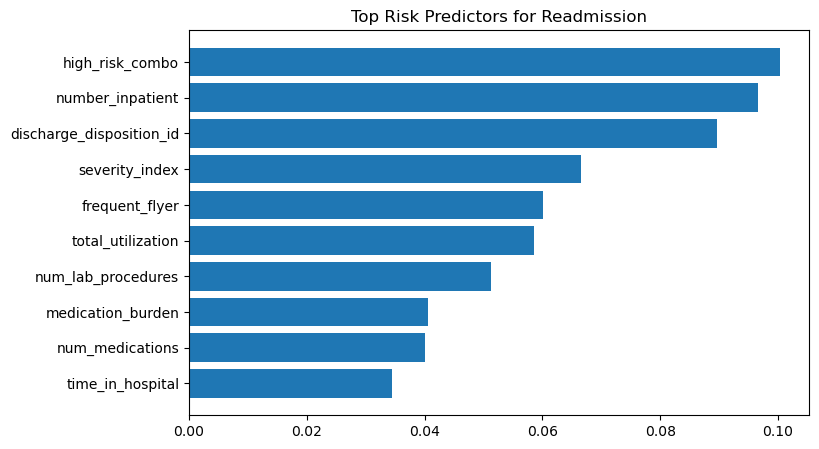

In [30]:
top_feats = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_feats["Feature"], top_feats["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Risk Predictors for Readmission")
plt.show()

In [31]:
x_shap = x_test.sample(500, random_state=42)

In [32]:
x_shap = x_shap.reset_index(drop=True)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(x_shap)

In [33]:
print(x_shap.shape)
print(len(shap_values))
print(shap_values[0].shape)
print(type(shap_values))

(500, 52)
500
(52, 2)
<class 'numpy.ndarray'>


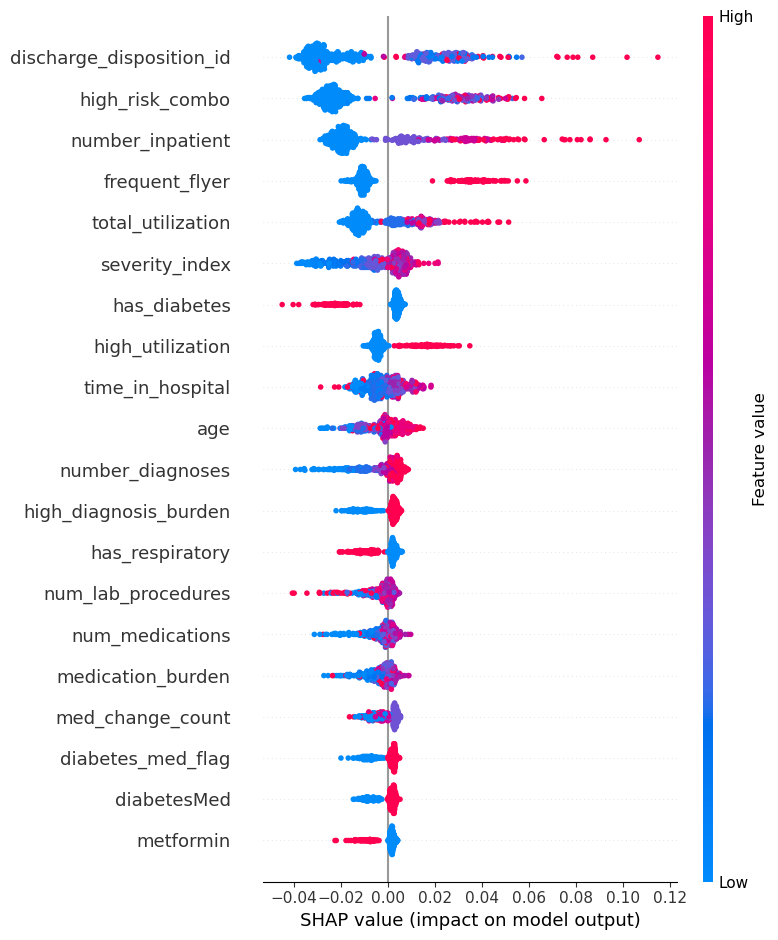

In [34]:
shap.summary_plot(shap_values[:, :, 1], x_shap)

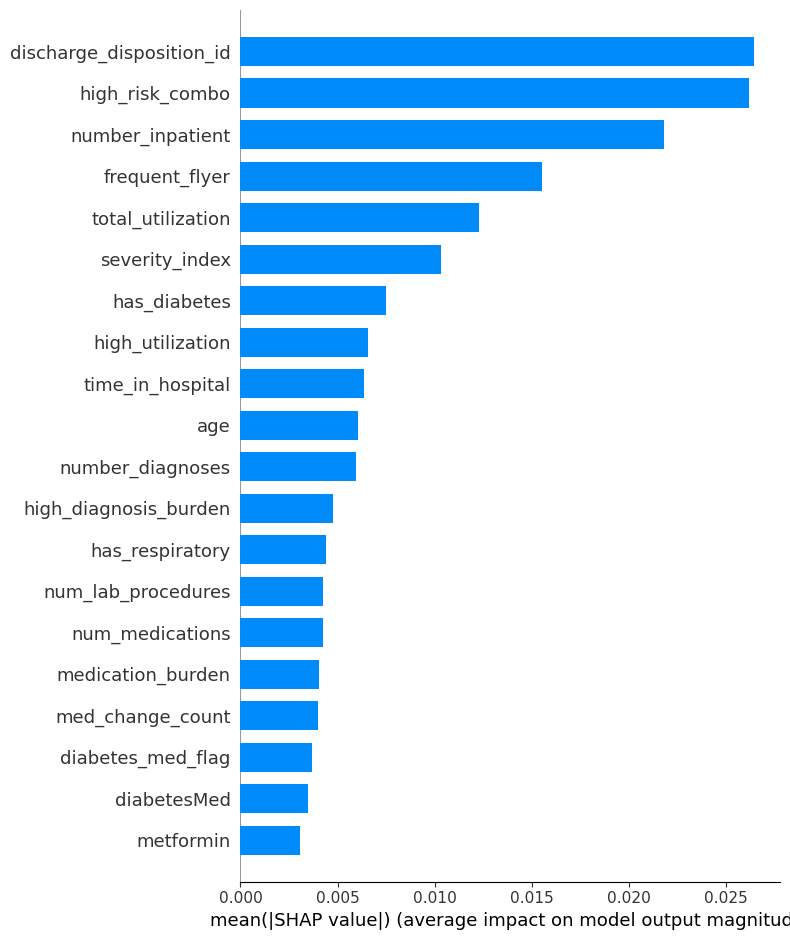

In [35]:
shap.summary_plot(

    shap_values[:,:,1],

    x_test,

    plot_type="bar"

)

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(x_test)

feature_names = x_test.columns

def get_top_features(shap_row, features, k=3):
    idx = np.argsort(np.abs(shap_row))[-k:]
    return ", ".join([f"{features[i]} ({shap_row[i]:.2f})" for i in idx])

In [47]:
results = x_test.copy()

results["Actual"] = y_test.values

results["Probability"] = y_prob

results["Prediction"] = y_pred_final

results.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,uses_insulin,diabetes_med_flag,has_diabetes,has_circulatory,has_respiratory,has_genitourinary,comorbidity_count,Actual,Probability,Prediction
99195,2,0,8,1,1,7,4,40,0,17,...,1,1,0,0,0,1,1,0,0.546017,1
63319,0,1,6,1,1,7,5,29,3,22,...,1,1,0,1,1,0,2,0,0.416102,1
64536,2,0,7,3,22,1,2,26,2,29,...,1,1,1,0,1,0,2,0,0.424451,1
13039,2,1,5,3,18,1,5,43,3,34,...,0,0,0,1,0,0,1,1,0.514108,1
37502,0,1,7,6,22,17,12,77,6,38,...,0,1,0,0,1,0,1,1,0.427998,1


In [48]:
def get_explanation(row):
    return "High inpatient visits + medication burden + comorbidity factors"

In [49]:
def recommend(row):

    recs = []

    if row["Prediction"] == 0:
        recs.append("Standard discharge")
    else:

        if row["frequent_flyer"] == 1:
            recs.append("Case management referral")

        if row["long_stay_risk"] == 1:
            recs.append("Early follow-up")

        if row["uses_insulin"] == 1:
            recs.append("Medication review")

        if row["high_utilization"] == 1:
            recs.append("Post-discharge monitoring")

        if row["high_diagnosis_burden"] == 1:
            recs.append("Specialist follow-up")

    return "; ".join(recs)

In [50]:
results["Recommendations"] = results.apply(recommend, axis=1)

In [51]:
results.to_csv(

     r"C:\Users\kayla\OneDrive\Documents\Readmission System\patient_predictions.csv",

    index=False

)

In [52]:
def simple_explanation(row):
    reasons = []
    
    if row["number_inpatient"] > 1:
        reasons.append("Frequent prior admissions")
    
    if row["time_in_hospital"] > 5:
        reasons.append("Extended hospital stay")
    
    if row["num_medications"] > 15:
        reasons.append("High medication burden")
    
    if row["comorbidity_count"] > 1:
        reasons.append("Multiple comorbidities")
    
    return "; ".join(reasons)

results["Risk_Explanation"] = results.apply(simple_explanation, axis=1)

In [ ]:
print("hello")

In [54]:
results.to_csv(r"C:\Users\kayla\OneDrive\Documents\Readmission System\patient_predictions.csv", index=False)

In [57]:
#Streamlit Dashboard

In [58]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [60]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [62]:
joblib.dump(list(x.columns), "feature_columns.pkl")

['feature_columns.pkl']